# SPORE quickstart

This notebook walks through the core workflow:

1. Loading a detector IRF and inspecting the effective area
2. Point source simulation (steady-state mode)
3. Extended source simulation
4. Sanity checks: Poisson statistics, Eddington bias, angular resolution vs energy

All paths are resolved relative to the repository root, so the notebook can be run from any working directory.

## 1  Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import tempfile
from pathlib import Path

import spore
from spore import (
    Detector, PointSource, ExtendedSource,
    PointSourceEventSampler, ExtendedSourceEventSampler,
    SkyCoordinate, ureg,
)

# Locate the repository root (works regardless of working directory)
_p = Path.cwd()
while not (_p / 'pyproject.toml').exists() and _p != _p.parent:
    _p = _p.parent
REPO_ROOT = _p
RESPONSE_FILE = str(REPO_ROOT / 'resources' / 'configs' / 'ps10yr_detector_response.h5')
print('repo root   :', REPO_ROOT)
print('response exists:', Path(RESPONSE_FILE).exists())

repo root   : /Users/jlazar/research/nedflix
response exists: True


## 2  Loading a detector

`Detector.from_config` accepts a plain dictionary.  We use the IceCube 10-year point-source sample response built by `scripts/build_ps10yr_detector_response.py`.

In [2]:
south_polar = Detector.from_config({
    'properties': {'latitude': -90.0, 'longitude': 0.0, 'medium': 'Ice'},
    'response':   {'detector_response_file': RESPONSE_FILE},
})

print('Location  : lat={:.1f} deg, lon={:.1f} deg'.format(
    np.degrees(south_polar.location.latitude), np.degrees(south_polar.location.longitude)))
print('Morphologies:', south_polar.response.available_morphologies)
effa = south_polar.response.effective_area['track']
print('A_eff range : {:.0f} GeV -- {:.2e} GeV'.format(
    effa.e_min_gev, effa.e_max_gev))

Location  : lat=-90.0 deg, lon=0.0 deg
Morphologies: ['track']
A_eff range : 126 GeV -- 7.94e+09 GeV


### 2.1  Effective area vs energy

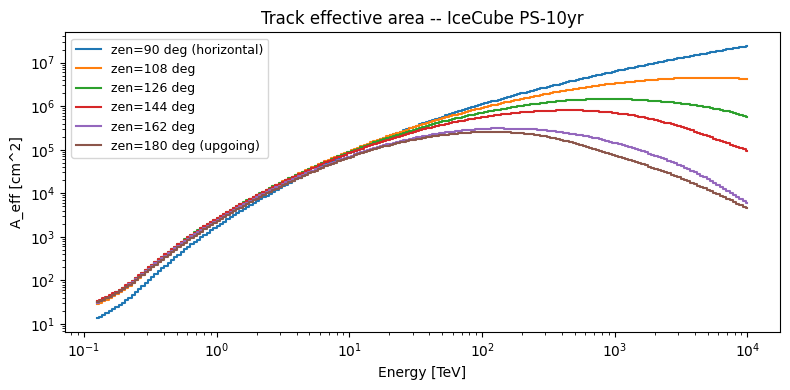

In [5]:
effa = south_polar.response.effective_area['track']
energies = np.logspace(np.log10(effa.e_min_gev), 7, 200)

zenith_cases = [
    (np.pi * 0.5, 'zen=90 deg (horizontal)'),
    (np.pi * 0.6, 'zen=108 deg'),
    (np.pi * 0.7, 'zen=126 deg'),
    (np.pi * 0.8, 'zen=144 deg'),
    (np.pi * 0.9, 'zen=162 deg'),
    (np.pi, 'zen=180 deg (upgoing)'),
]

fig, ax = plt.subplots(figsize=(8, 4))
for zen, label in zenith_cases:
    vals = effa(np.full(len(energies), zen), energies)
    ax.step(energies / 1e3, vals, label=label, where="mid")

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Energy [TeV]')
ax.set_ylabel('A_eff [cm^2]')
ax.set_title('Track effective area -- IceCube PS-10yr')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### 2.2  PSF median angular resolution vs energy

When the detector response stores a standalone `angular_response` callable, `angular_response(E, 0.5)` gives the median PSF deflection at energy E.  The IceCube PS-10yr response uses a joint smearing table instead, so no standalone angular-response callable is available here; we skip this plot and demonstrate angular resolution empirically in section 5.2.

In [6]:
ang = south_polar.response.angular_response['track']
if ang is not None:
    e_grid = np.logspace(np.log10(effa.e_min_gev), np.log10(effa.e_max_gev), 80)
    median_psf_deg = np.degrees([ang(e, 0.5) for e in e_grid])

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(e_grid / 1e3, median_psf_deg, color='steelblue')
    ax.set_xscale('log')
    ax.set_xlabel('Energy [TeV]')
    ax.set_ylabel('Median PSF [deg]')
    ax.set_title('Track angular resolution (median) -- IceCube PS-10yr')
    plt.tight_layout()
    plt.show()
else:
    print('angular_response not available for this detector response '
          '(joint smearing IRF); see section 5.2 for empirical PSF.')

angular_response not available for this detector response (joint smearing IRF); see section 5.2 for empirical PSF.


## 3  Point source simulation

We simulate TXS 0506+056 (dec +5.7 deg), the first IceCube blazar candidate, with a soft E^-2.7 power-law spectrum.  `n_time_samples=100` enables steady-state mode: the effective area is averaged over 100 hour-angle samples uniformly spaced over one diurnal cycle.  This is the correct treatment for observations spanning many sidereal days.

In [7]:
src = PointSource.from_config({
    'flux': {
        'norm':  1e-14,   # GeV^-1 cm^-2 s^-1 per species
        'gamma': 2.7,
        'pivot': 1e3,     # 1 TeV
        'emin':  1e2,
        'emax':  1e7,
    },
    'location': {'declination': 5.7, 'right_ascension': 77.4},
})
print('Source: dec={:.2f} deg, RA={:.2f} deg'.format(
    np.degrees(src.location.declination),
    np.degrees(src.location.right_ascension)))

Source: dec=5.70 deg, RA=77.40 deg


In [8]:
sampler_ps = PointSourceEventSampler(south_polar, src, n_time_samples=100)

one_year = ureg.Quantity(365.25, 'day')
n_exp = sampler_ps.expected_events('track', one_year)
print(f'Expected track events in one year: {n_exp:.2f}')

Expected track events in one year: 8.66


### 3.1  Sample ten years of events (Poisson mode)

In [9]:
events_ps = sampler_ps.sample_events('track', deltat=10 * one_year, seed=1)
print(f'Sampled {len(events_ps)} events')

true_e_tev  = np.array([ev.true_energy.to('TeV').magnitude  for ev in events_ps])
reco_e_tev  = np.array([ev.reco_energy.to('TeV').magnitude  for ev in events_ps])
reco_decs   = np.degrees([ev.reco_direction.declination      for ev in events_ps])
reco_ras    = np.degrees([ev.reco_direction.right_ascension  for ev in events_ps])
ang_seps    = np.degrees([ev.true_direction.separation(ev.reco_direction)
                          for ev in events_ps])

Sampled 87 events


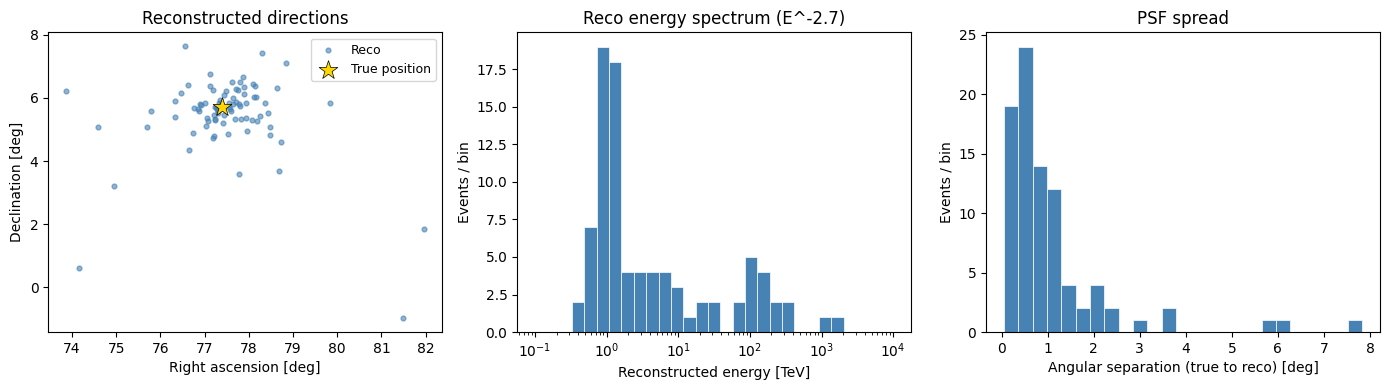

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
src_dec = np.degrees(src.location.declination)
src_ra  = np.degrees(src.location.right_ascension)

ax = axes[0]
ax.scatter(reco_ras, reco_decs, s=12, alpha=0.6, color='steelblue', label='Reco')
ax.scatter([src_ra], [src_dec], s=200, marker='*', color='gold',
           zorder=5, label='True position', edgecolors='k', linewidths=0.5)
ax.set_xlabel('Right ascension [deg]')
ax.set_ylabel('Declination [deg]')
ax.set_title('Reconstructed directions')
ax.legend(fontsize=9)

ax = axes[1]
bins = np.logspace(-1, 4, 30)
ax.hist(reco_e_tev, bins=bins, color='steelblue', edgecolor='white', lw=0.5)
ax.set_xscale('log')
ax.set_xlabel('Reconstructed energy [TeV]')
ax.set_ylabel('Events / bin')
ax.set_title('Reco energy spectrum (E^-2.7)')

ax = axes[2]
ax.hist(ang_seps, bins=25, color='steelblue', edgecolor='white', lw=0.5)
ax.set_xlabel('Angular separation (true to reco) [deg]')
ax.set_ylabel('Events / bin')
ax.set_title('PSF spread')

plt.tight_layout()
plt.show()

### 3.2  True vs reconstructed energy

For steeply falling spectra the energy resolution causes more events to scatter *upward* in energy than downward (Eddington bias).  We can see this directly by comparing E_true and E_reco for the same events.

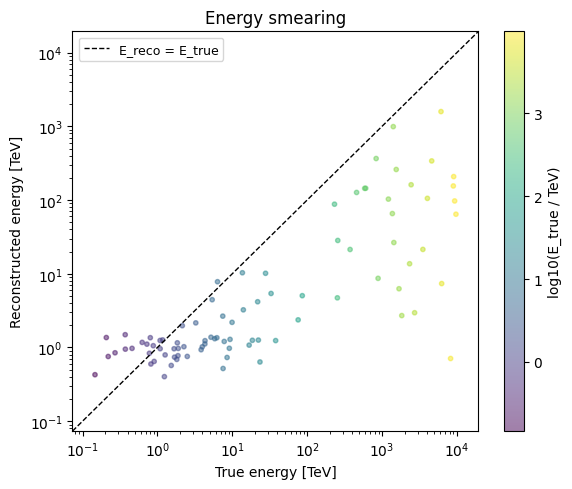

In [11]:
fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(true_e_tev, reco_e_tev, s=10, alpha=0.5,
                c=np.log10(true_e_tev), cmap='viridis')
lim = [min(true_e_tev.min(), reco_e_tev.min()) * 0.5,
       max(true_e_tev.max(), reco_e_tev.max()) * 2.0]
ax.plot(lim, lim, 'k--', lw=1, label='E_reco = E_true')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('True energy [TeV]')
ax.set_ylabel('Reconstructed energy [TeV]')
ax.set_title('Energy smearing')
plt.colorbar(sc, ax=ax, label='log10(E_true / TeV)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 4  Extended source simulation

We model an isotropic diffuse E^-2 astrophysical flux.  The flux is written to a temporary HDF5 file and loaded via `ExtendedSource.from_config`.  The sampler runs in steady-state mode (diurnal-average A_eff).

In [12]:
N_DEC, N_E  = 30, 40
sindecs     = np.linspace(-1.0, 1.0, N_DEC)
energies    = np.logspace(2.0, 6.0, N_E)   # 100 GeV -- 1 PeV

PHI_0 = 1e-18   # GeV^-1 cm^-2 s^-1 sr^-1 per species
phi   = PHI_0 * (energies / 1e5) ** (-2.0)

fluxes      = np.zeros((6, N_DEC, N_E))
fluxes[2]   = phi[np.newaxis, :]   # nu_mu
fluxes[3]   = phi[np.newaxis, :]   # nu_mu_bar

_tmpdir   = tempfile.mkdtemp()
FLUX_FILE = str(Path(_tmpdir) / 'isotropic_flux.h5')

with h5py.File(FLUX_FILE, 'w') as f:
    grp = f.create_group('flux')
    grp.create_dataset('sindecs',  data=sindecs)
    grp.create_dataset('energies', data=energies)
    grp.create_dataset('fluxes',   data=fluxes)

print('Flux file written to', FLUX_FILE)

Flux file written to /var/folders/rr/4sp_7qnn509b31qkr6c2_6sr0000gp/T/tmp7xya0yl_/isotropic_flux.h5


In [13]:
src_ext = ExtendedSource.from_config({'flux': {'location': f'{FLUX_FILE}:flux'}})

print('Building extended-source sampler (steady-state)...')
sampler_ext = ExtendedSourceEventSampler(
    south_polar, src_ext,
    n_dec=30, n_ra=30, n_e=30,
    n_time_samples=100,
)

n_exp_ext = sampler_ext.expected_events('track', one_year)
print(f'Expected track events in one year: {n_exp_ext:.1f}')

Building extended-source sampler (steady-state)...
Expected track events in one year: 217.4


In [14]:
events_ext  = sampler_ext.sample_events('track', deltat=one_year, seed=2)
print(f'Sampled {len(events_ext)} events')

ext_decs   = np.degrees([ev.true_direction.declination     for ev in events_ext])
ext_log10e = [np.log10(ev.reco_energy.to('GeV').magnitude) for ev in events_ext]

Sampled 207 events


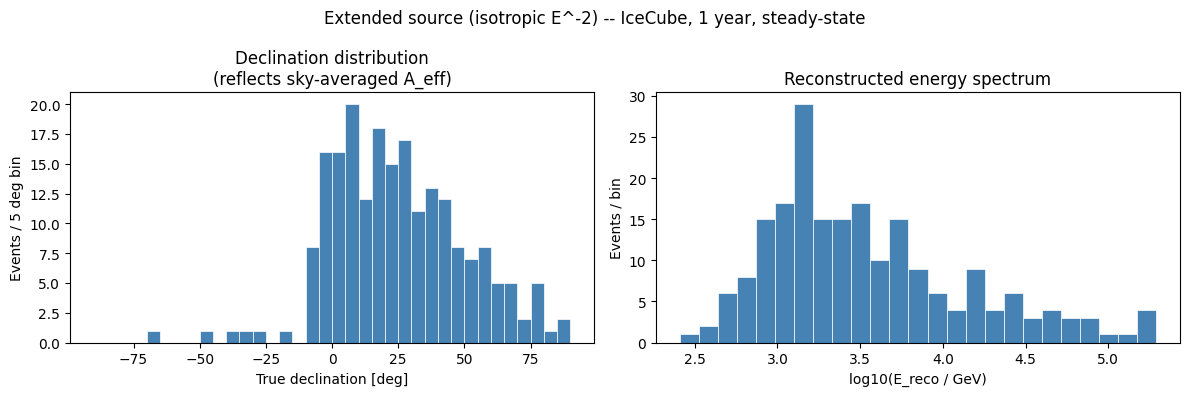

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Extended source (isotropic E^-2) -- IceCube, 1 year, steady-state')

ax = axes[0]
ax.hist(ext_decs, bins=np.linspace(-90, 90, 37),
        color='steelblue', edgecolor='white', lw=0.5)
ax.set_xlabel('True declination [deg]')
ax.set_ylabel('Events / 5 deg bin')
ax.set_title('Declination distribution\n(reflects sky-averaged A_eff)')

ax = axes[1]
ax.hist(ext_log10e, bins=25, color='steelblue', edgecolor='white', lw=0.5)
ax.set_xlabel('log10(E_reco / GeV)')
ax.set_ylabel('Events / bin')
ax.set_title('Reconstructed energy spectrum')

plt.tight_layout()
plt.show()

## 5  Sanity checks

### 5.1  Poisson statistics

Run 300 pseudo-experiments and check that the event count distribution matches Poisson(expected).

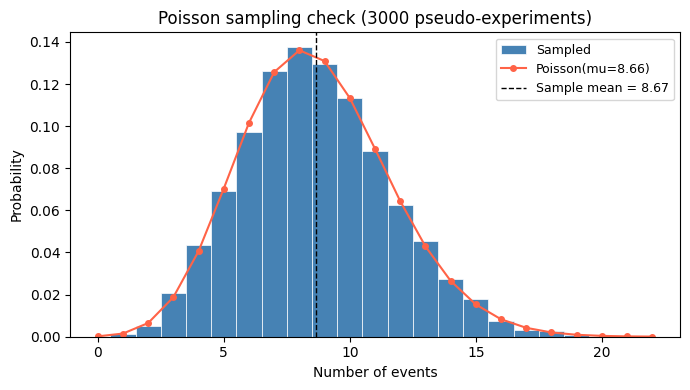

Expected mean : 8.66
Poisson std   : 2.94
Sample mean   : 8.67  (std 2.94)


In [16]:
N_PSEUDO = 3000
counts = np.array([
    len(sampler_ps.sample_events('track', deltat=one_year, seed=i))
    for i in range(N_PSEUDO)
])

from scipy.stats import poisson as scipy_poisson
k = np.arange(max(0, counts.min() - 3), counts.max() + 4)
pmf = scipy_poisson.pmf(k, n_exp)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(counts, bins=np.arange(counts.min() - 0.5, counts.max() + 1.5),
        density=True, color='steelblue', edgecolor='white', lw=0.5, label='Sampled')
ax.plot(k, pmf, 'o-', color='tomato', ms=4,
        label=f'Poisson(mu={n_exp:.2f})')
ax.axvline(counts.mean(), color='k', ls='--', lw=1,
           label=f'Sample mean = {counts.mean():.2f}')
ax.set_xlabel('Number of events')
ax.set_ylabel('Probability')
ax.set_title(f'Poisson sampling check ({N_PSEUDO} pseudo-experiments)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'Expected mean : {n_exp:.2f}')
print(f'Poisson std   : {n_exp**0.5:.2f}')
print(f'Sample mean   : {counts.mean():.2f}  (std {counts.std():.2f})')

### 5.2  Angular resolution vs reconstructed energy

The PSF should decrease with increasing energy. We sample a large fixed set and measure the median angular separation per energy bin.

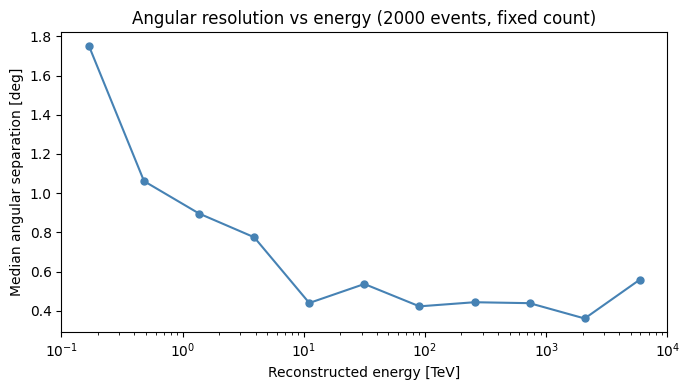

In [17]:
events_large = sampler_ps.sample_events('track', nevent=2000, seed=3)

e_reco = np.array([ev.reco_energy.to('TeV').magnitude for ev in events_large])
sep    = np.degrees([ev.true_direction.separation(ev.reco_direction)
                     for ev in events_large])

e_bins  = np.logspace(-1, 4, 12)
e_mids  = np.sqrt(e_bins[:-1] * e_bins[1:])
med_sep = []
for lo, hi in zip(e_bins[:-1], e_bins[1:]):
    mask = (e_reco >= lo) & (e_reco < hi)
    med_sep.append(np.median(sep[mask]) if mask.sum() > 0 else np.nan)
med_sep = np.array(med_sep)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(e_mids, med_sep, 'o-', color='steelblue', ms=5)
ax.set_xscale('log')
ax.set_xlabel('Reconstructed energy [TeV]')
ax.set_ylabel('Median angular separation [deg]')
ax.set_title('Angular resolution vs energy (2000 events, fixed count)')
plt.tight_layout()
plt.show()

In [18]:
mediterranean = Detector.from_config({
    'properties': {'latitude': 36.3, 'longitude': 16.1, 'depth': 3500, 'medium': 'Water'},
    'response':   {'detector_response_file': RESPONSE_FILE},
})

In [32]:
sampler_ps_both = PointSourceEventSampler([south_polar, mediterranean], src, n_time_samples=100)
joint_events = sampler_ps_both.sample_events("track", deltat=10 * one_year)

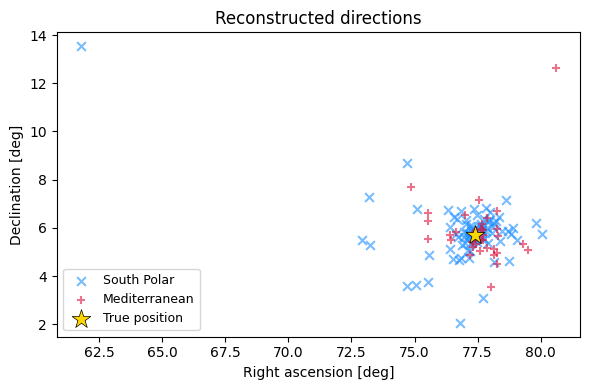

In [37]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
src_dec = np.degrees(src.location.declination)
src_ra  = np.degrees(src.location.right_ascension)

ax.scatter(
    np.degrees([ev.reco_direction.right_ascension for ev in joint_events if ev.detector_id==0]),
    np.degrees([ev.reco_direction.declination for ev in joint_events if ev.detector_id==0]),
    s=40, 
    alpha=0.6,
    color='dodgerblue',
    label='South Polar',
    marker="x"
)

ax.scatter(
    np.degrees([ev.reco_direction.right_ascension for ev in joint_events if ev.detector_id==1]),
    np.degrees([ev.reco_direction.declination for ev in joint_events if ev.detector_id==1]),
    s=40, 
    alpha=0.6,
    color='crimson',
    label='Mediterranean',
    marker="+"
)
ax.scatter([src_ra], [src_dec], s=200, marker='*', color='gold',
           zorder=5, label='True position', edgecolors='k', linewidths=0.5)
ax.set_xlabel('Right ascension [deg]')
ax.set_ylabel('Declination [deg]')
ax.set_title('Reconstructed directions')
ax.legend(fontsize=9)

# ax = axes[1]
# bins = np.logspace(-1, 4, 30)
# ax.hist(reco_e_tev, bins=bins, color='steelblue', edgecolor='white', lw=0.5)
# ax.set_xscale('log')
# ax.set_xlabel('Reconstructed energy [TeV]')
# ax.set_ylabel('Events / bin')
# ax.set_title('Reco energy spectrum (E^-2.7)')

# ax = axes[2]
# ax.hist(ang_seps, bins=25, color='steelblue', edgecolor='white', lw=0.5)
# ax.set_xlabel('Angular separation (true to reco) [deg]')
# ax.set_ylabel('Events / bin')
# ax.set_title('PSF spread')

plt.tight_layout()
plt.show()